# 4) Nuclei & Cell Segmentation with Cellpose - Tutorial

[Cellpose](https://cellpose.readthedocs.io/en/latest/) is a segmentation method widely used for labeling cells and nuclei in microscopy data. It is based on deep learning models and the newest paper can be read [here](https://doi.org/10.1101/2025.04.28.651001).

We are running this notebook on the google cloud but you can run this notebook also locally, for instructions on how to install see [here](https://github.com/MouseLand/cellpose).

### On google Colab: Make sure you have GPU access enabled by going to Runtime -> Change Runtime Type -> Hardware accelerator and selecting GPU

In [1]:
# install cellpose, matplotlib
!pip install cellpose matplotlib
!git clone https://github.com/mirandaresearchlab/LCI_Workshop_2026.git
!rm -rf sample_data

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.2/212.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 46.3 MB/s eta 0:00:00
Cloning into 'LCI_Workshop_2026'...
remote: Enumerating objects: 316, done.
remote: Counting objects: 100% (83/83), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 316 (delta 70), reused 80 (delta 69), pack-reused 233 (from 1)
Receiving objects: 100% (316/316), 31.25 MiB | 23.10 MiB/s, done.
Resolving deltas: 100% (92/92), done.


### Import necessary libraries

Here we start running the notebook by importing the libraries we need.

In [ ]:
from cellpose import models, io
import os
import numpy as np
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
model = models.CellposeModel(gpu=True)
import skimage


100%|██████████| 1.15G/1.15G [00:11<00:00, 104MB/s]


### Open file and predict masks

Below the path to the example image from the github repository is loaded. You can change the path to another image if you want.

Then, the cells are labeled with Cellpose.

In [ ]:
file_name = 'LCI_Workshop_2026/images/Nuclei_no_avg.tif'
file = io.imread(file_name)

# background subtraction with rolling ball
background = skimage.restoration.rolling_ball(file, radius=50)
file = file - background

masks_pred, flows, styles = model.eval(file)

### Visualize masks and save mask

Lastly, the predicted masks are visualized side-by-side to the initial image and saved in the same folder with attaching '_mask' to the file name.

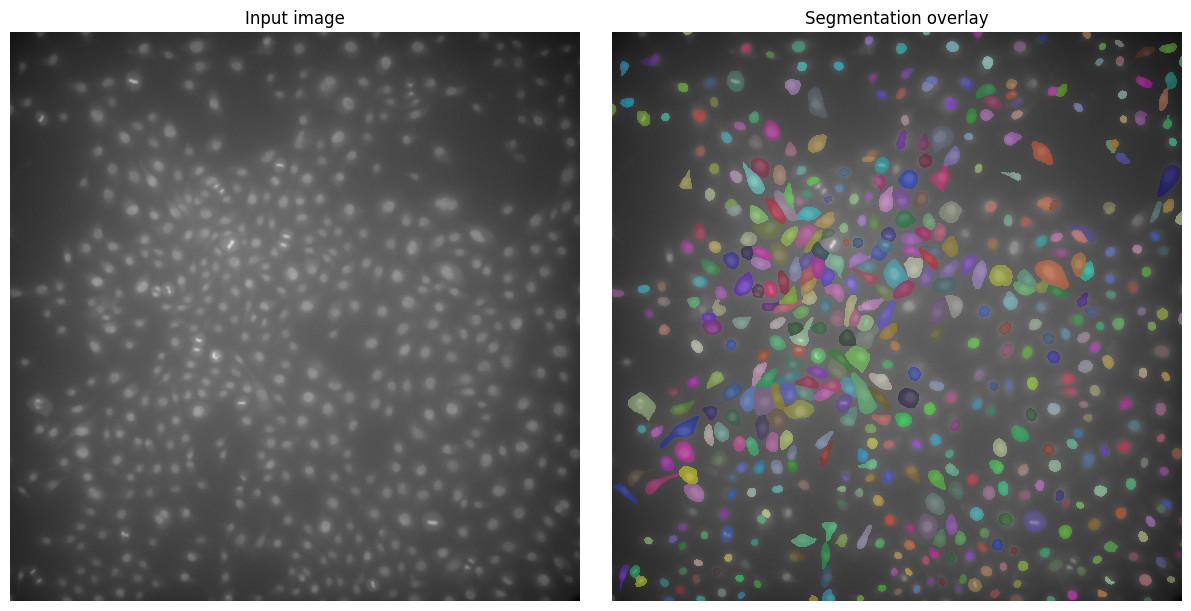

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

axes[0].imshow(file, cmap="gray")
axes[0].set_title("Input image")
axes[0].axis("off")

axes[1].imshow(file, cmap="gray")
n = int(masks_pred.max()) + 1
rng = np.random.default_rng(0)

colors = rng.random((n, 4))
colors[:, 3] = 0.45
colors[0, 3] = 0.0
cmap = ListedColormap(colors)

axes[1].imshow(np.ma.masked_equal(masks_pred, 0), cmap=cmap, interpolation="nearest")
axes[1].set_title("Segmentation overlay")
axes[1].axis("off")

plt.show()
io.imsave(file_name.replace('.tif', '_mask.tif'), masks_pred.astype(np.uint16))

After that, you can open the .tif mask file in FIJI and convert the grayscale mask into ROIs with PTBIOP (https://github.com/BIOP/ijp-LaRoMe).

- Install Fiji plugin by Help > Update... > Manage Update Sites > select PTBIOP in the list > Apply changes > Restart Fiji
- Drag and drop file into FIJI
- Plugins > BIOP > Image Analysis > ROIs > Label Image to ROIs

## Run cellpose on your own data

To run cellpose on your own data, upload your data to google drive and connect this notebook to it by running the below command. You will be prompted to give access. You do not need to give access for anything related to drive desktop.

In [5]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


### Define your data path

In this cell below you define the path to a folder within your google drive. You have to change anything that is after '/content/drive/MyDrive/' and add your folder name to it. If for example your folder located in the google drive is called 'LCI2026' the path would be called '/content/drive/MyDrive/LCI2026'. Next, all files in the folder are listed.

In [6]:
image_path = "/content/drive/MyDrive/test_data_lci/"
list_of_files = os.listdir(image_path)
print(list_of_files)

['tissue1.tif', 'tissue2.tif']


Below, all files ending in "tif" or "tiff" will be segmented, visualized and saved.

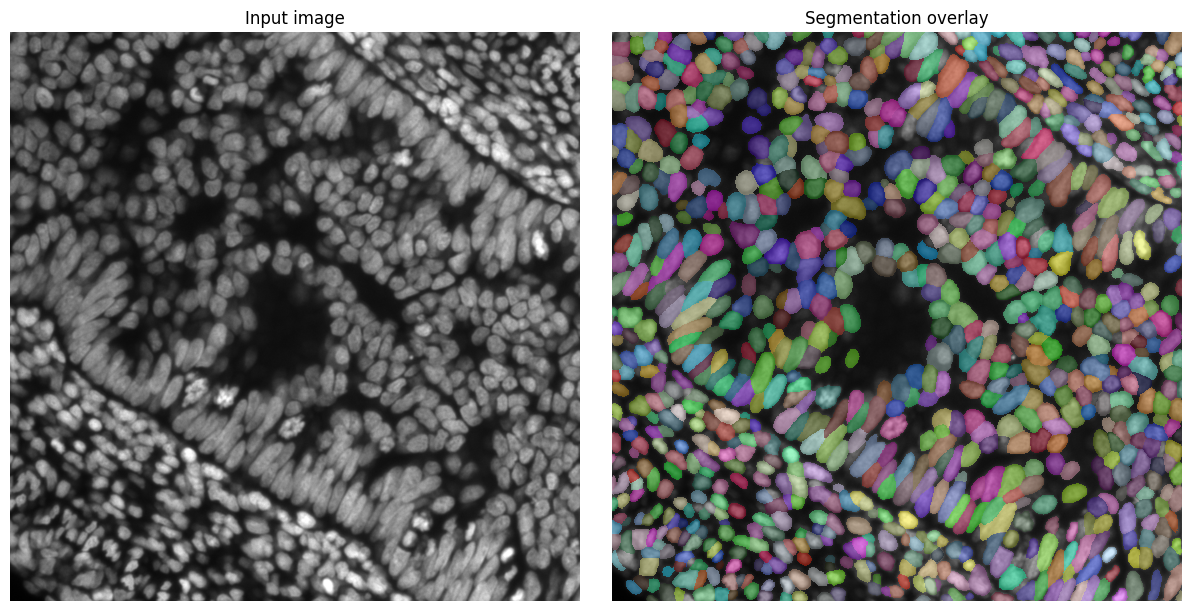

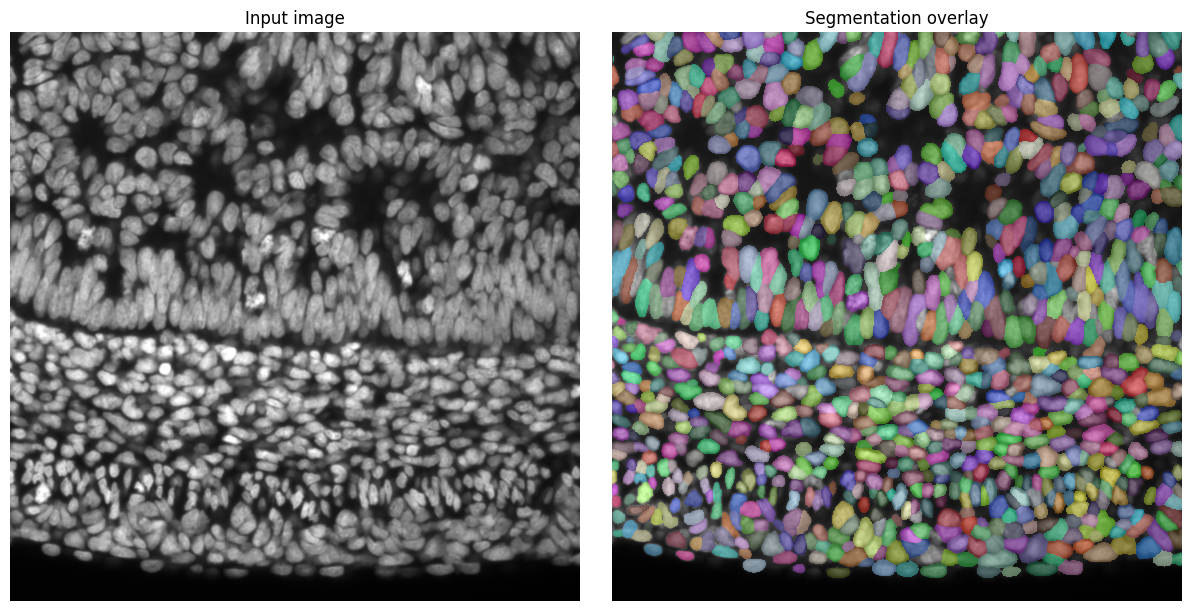

In [8]:
for file_name in list_of_files:
  if file_name.endswith(".tif") or file_name.endswith(".tiff"):
    file = io.imread(os.path.join(image_path, file_name))
    masks_pred, flows, styles = model.eval(file)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

    axes[0].imshow(file, cmap="gray")
    axes[0].set_title("Input image")
    axes[0].axis("off")

    axes[1].imshow(file, cmap="gray")
    n = int(masks_pred.max()) + 1
    rng = np.random.default_rng(0)

    colors = rng.random((n, 4))
    colors[:, 3] = 0.45
    colors[0, 3] = 0.0
    cmap = ListedColormap(colors)

    axes[1].imshow(np.ma.masked_equal(masks_pred, 0), cmap=cmap, interpolation="nearest")
    axes[1].set_title("Segmentation overlay")
    axes[1].axis("off")
    plt.show()
    io.imsave(f"{image_path + file_name.split('.')[0]}_mask.tif", masks_pred.astype(np.uint16))